# Mathematik II/B — Übung 02 (WT 2026)

**Thema:** [Thema eintragen]
**Datum:** [Datum eintragen]
**Dozent/in:** [Name eintragen]

---

## 📖 Inhaltsverzeichnis

0. [🔄 Wiederholung – Aus Übung 01](#wiederholung)
1. [📖 Theoretischer Hintergrund](#theorie)
2. [📝 Aufgabeblatt 02 – Mathematik II/B Übung 02](#aufgabeblatt)
   - [Aufgabe 2.1](#aufgabe1)
   - [Aufgabe 2.2](#aufgabe2)
   - [Aufgabe 2.3](#aufgabe3)
   - [Aufgabe 2.5](#aufgabe4)
   - [Aufgabe 2.5](#aufgabe5)
   - [Aufgabe 2.6](#aufgabe6)
   - [Aufgabe 2.7](#aufgabe7)
   - [Aufgabe 2.8](#aufgabe8)



3. [💡 Lösungstipps](#tipps)

---

In [4]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import math
import sympy as sp
import pandas as pd
from IPython.display import display, Math, HTML, Markdown

from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, interactive
import ipywidgets as widgets

# Konfiguration für schönere Plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Alle Pakete erfolgreich geladen!")

ModuleNotFoundError: No module named 'pandas'

<a id="wiederholung"></a>
## 🔄 Wiederholung – Aus Übung 01

Zur Auffrischung: 

In Blatt 1 (Analysis) haben wir unser Fundament gefestigt. Die Schwerpunkte lagen auf:

Funktionsverständnis: Wie verhalten sich Grundfunktionen (Polynomial-, Trigono-, Exponentialfunktionen) und wie wirken sich Verschiebungen und Streckungen aus?

Konvergenz & Präzision: Das Verständnis des Grenzwertbegriffs durch das ϵ-N-Kriterium (∣a 
n
​	
 −a∣<ϵ).

Differentialrechnung: Die Anwendung der Ableitungsregeln (Produkt-, Quotienten- und Kettenregel) auf komplexe Terme.

Die Folgenden Aufgaben ermöglichen Ihnen sich an das letzte Thema zu erinnern:

1. Aufgabe: Funktionsplotter
Wir visualisieren drei verschiedene Funktionstypen in einem Plot, um die Unterschiede im Wachstum zu verdeutlichen

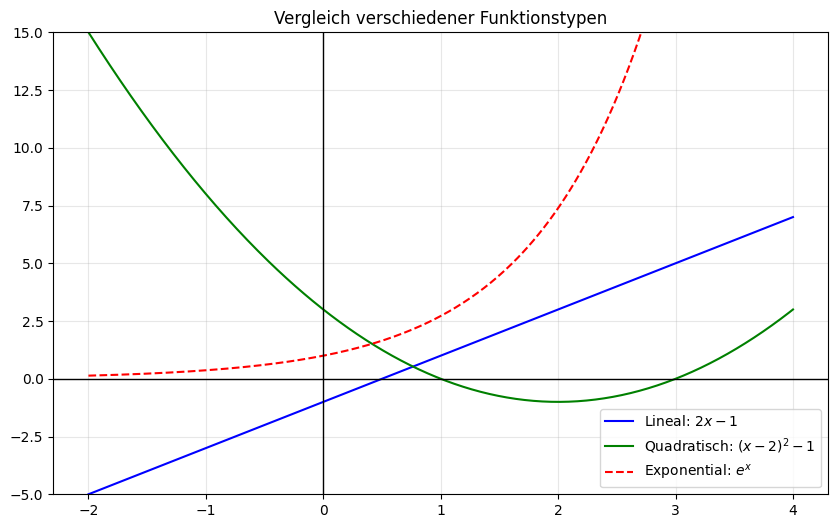

In [ ]:
# Definition der Funktionen
x_vals = np.linspace(-2, 4, 400)
p_lin = 2 * x_vals - 1        # Aufgabe 1.1a
p_quad = (x_vals - 2)**2 - 1  # Aufgabe 1.1b
p_exp = np.exp(x_vals)        # Aufgabe 1.1o

plt.figure(figsize=(10, 6))
plt.plot(x_vals, p_lin, label='Lineal: $2x-1$', color='blue')
plt.plot(x_vals, p_quad, label='Quadratisch: $(x-2)^2-1$', color='green')
plt.plot(x_vals, p_exp, label='Exponential: $e^x$', color='red', linestyle='--')

# Achsen und Styling
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.ylim(-5, 15)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Vergleich verschiedener Funktionstypen")
plt.show()

In [ ]:
2. Visualisierung der Konvergenz

In [ ]:
n_indices = np.arange(1, 15000, 100)
a_n_vals = 1 / np.sqrt(n_indices)
epsilon = 0.01

# Nutze r'...' für Strings mit Backslashes (LaTeX)
plt.plot(n_indices, a_n_vals, label=r'$a_n = 1/\sqrt{n}$')
plt.axhline(epsilon, color='red', linestyle='--', label=r'$\epsilon = 0.01$')
plt.axvline(10000, color='green', linestyle=':', label='$N = 10000$')

plt.xlabel('n')
plt.ylabel('Wert')
plt.title("Visualisierung der Konvergenz")
plt.legend()
plt.show()

NameError: name 'np' is not defined

In [ ]:
# Aufgaben 2.1-2.4, 2.5-2.6
# nicht alle Teilaufgaben müssen hier visualisiert/gelöst werden, damit es übersichtlich bleibt
# Die Auswahl der Teilaufgaben überlassen wir Ihnen
# Wenn möglich, alle Fälle (konvergent, divergent, oszillierend) müssen visualisiert werden, damit die Konzepte klar werden.
# Es sollten auch die Methoden zur Bestimmung der Konvergenz (z.B. Quotientenkriterium, Wurzelkriterium, etc.) gezeigt werden (auch visuel wo möglich)
# Wiederholungs-Widget Code hier einfügen
# (Optional: Sie können hier die create_solution_toggle Funktion von Mathematik_II_Uebung.ipynb kopieren)
# Konvergenz-Widget Code hier einfügen z. B. aus der Aufgaben 2.1-2.4
# oder Sie schreiben Ihren eigenen Code, um die Konvergenz der frei ausgewählten Folge zu visualisieren.
# Sie können mehrere Wiederholungsaufgaben und Konvergenz-Widgets in diesem Notebook erstellen, um die verschiedenen Konzepte zu vertiefen und zu visualisieren.

<a id="theorie"></a>
## 📖 Theoretischer Hintergrund

Theoretischer Hintergrund zu Blatt 2: Folgen, Stetigkeit und Ableitungen

In diesem Abschnitt fassen wir die mathematischen Kernkonzepte zusammen, die für die Bearbeitung von Blatt 2 essenziell sind.

---

### 1. Die $\epsilon$-$N$-Definition der Konvergenz
Eine Folge $(a_n)_{n \in \mathbb{N}}$ konvergiert gegen den Grenzwert $a$, wenn die Folgenglieder für wachsendes $n$ dem Wert $a$ beliebig nahe kommen. Präzise formuliert:
$$\forall \epsilon > 0 \quad \exists N(\epsilon) \in \mathbb{R} : \forall n > N(\epsilon) \implies |a_n - a| < \epsilon$$
Das bedeutet: Für jede noch so kleine Fehlerschranke $\epsilon$ lässt sich ein Index $N$ finden, ab dem alle weiteren Folgenglieder im "$\epsilon$-Schlauch" um den Grenzwert liegen.

### 2. Der Einschließungssatz (Sandwich-Theorem)
Wenn für drei Folgen $(a_n), (b_n), (c_n)$ ab einem bestimmten Index gilt:
$$a_n \leq b_n \leq c_n$$
und sowohl $\lim_{n \to \infty} a_n = a$ als auch $\lim_{n \to \infty} c_n = a$, dann folgt zwingend:
$$\lim_{n \to \infty} b_n = a$$
Dies ist besonders nützlich bei Folgen mit oszillierenden Anteilen (wie $\cos(n)$ oder $(-1)^n$), die durch Nullfolgen eingegrenzt werden können.

### 3. Stetigkeit und Unstetigkeitsstellen
Eine Funktion $f$ ist an der Stelle $x_0$ stetig, wenn der Grenzwert existiert und mit dem Funktionswert übereinstimmt:
$$\lim_{x \to x_0} f(x) = f(x_0)$$
Ist dies nicht der Fall, liegt eine Unstetigkeit vor:
* **Hebbare Unstetigkeit:** $\lim_{x \to x_0} f(x)$ existiert, ist aber $\neq f(x_0)$.
* **Sprungstelle:** Der linksseitige Grenzwert $\lim_{x \to x_0^-} f(x)$ und der rechtsseitige Grenzwert $\lim_{x \to x_0^+} f(x)$ sind beide endlich, aber verschieden.
* **Polstelle:** Die Funktionswerte streben gegen $\pm \infty$.

### 4. Logarithmisches Differenzieren
Bei Funktionen der Form $f(x) = g(x)^{h(x)}$ (insbesondere $x^x$) nutzen wir die Identität:
$$f(x) = e^{h(x) \cdot \ln(g(x))}$$
Die Ableitung erfolgt dann über die Kettenregel:
$$f'(x) = e^{h(x) \cdot \ln(g(x))} \cdot \frac{d}{dx} \left[ h(x) \cdot \ln(g(x)) \right]$$

### 5. Höhere Ableitungen
Die $n$-te Ableitung $f^{(n)}(x)$ wird durch sukzessives Differenzieren bestimmt. Bei Funktionen wie $\sin(ax)$ oder $e^{ax}$ lassen sich oft allgemeine Bildungsgesetze in Abhängigkeit von $n$ finden (z.B. Vorzeichenwechsel oder Potenzen der inneren Ableitung).


<a id="aufgabe1"></a>
## 📝 Aufgaben 2.1 und 2.2

###  Analyse des Konvergenzverhaltens

Das Ziel dieser Untersuchung ist es, ein intuitives Verständnis für die verschiedenen Arten der Folgenkonvergenz zu entwickeln. In der Analysis unterscheiden wir grundlegend:

1.  **Konvergenz:** Die Folge nähert sich einem festen Wert $a$ an. Ab einem Index $N$ liegen alle weiteren Glieder im $\epsilon$-Schlauch.
2.  **Divergenz (Bestimmt):** Die Folge wächst über alle Grenzen ($\pm \infty$).
3.  **Divergenz (Unbestimmt/Oszillierend):** Die Folge springt zwischen Werten hin und her, ohne sich zu stabilisieren.
4.  **Einschließung (Sandwich):** Eine komplizierte Folge wird von zwei einfacheren Nullfolgen "eingezwängt".

**Deine Aufgabe:**
Nutze das untenstehende Widget, um für die verschiedenen Folgentypen den passenden **$\epsilon$-Schlauch** einzustellen. 
- Beobachte bei der konvergenten Folge, wie sich der Index $N$ nach rechts verschiebt, wenn du $\epsilon$ kleiner machst.
- Überlege bei der oszillierenden Folge, warum kein $N$ gefunden werden kann, egal wie groß du den Schlauch wählst.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

def check_sequence_behavior(folgentyp, epsilon):
    n = np.arange(1, 101)
    limit = None
    show_n_marker = False
    
    # 1. Konvergent (Blatt 2.1a)
    if folgentyp == 'Konvergent: 1/n':
        a_n = 1/n
        limit = 0
        show_n_marker = True
        label_str = r'$a_n = \frac{1}{n}$'
    
    # 2. Bestimmt Divergent (Blatt 2.2b)
    elif folgentyp == 'Divergent: n^2 / (5n-1)':
        a_n = (n**2) / (5*n - 1)
        label_str = r'$a_n = \frac{n^2}{5n-1}$'
        
    # 3. Oszillierend (Divergent)
    elif folgentyp == 'Oszillierend: (-1)^n * (1-1/n)':
        a_n = ((-1.0)**n) * (1 - 1/n)
        label_str = r'$a_n = (-1)^n \cdot (1-\frac{1}{n})$'
        
    # 4. Sandwich / Einschließung (Blatt 2.1 b-v)
    elif folgentyp == 'Sandwich: cos(n)/n':
        a_n = np.cos(n) / n
        limit = 0
        show_n_marker = True
        label_str = r'$a_n = \frac{\cos(n)}{n}$'

    plt.figure(figsize=(12, 6))
    
    # Plot der Folgenglieder
    plt.plot(n, a_n, 'o', color='#1f77b4', markersize=5, label='Folgenglieder $a_n$')
    
    # Zeichnen des Grenzwerts und des Epsilon-Schlauchs
    if limit is not None:
        plt.axhline(limit, color='black', linewidth=1.5, label=f'Grenzwert $a = {limit}$')
        plt.fill_between(n, limit - epsilon, limit + epsilon, color='red', alpha=0.15, 
                         label=rf'$\epsilon$-Schlauch ($\epsilon = {epsilon}$)')
        
        # Berechnung von N: Ab wann ist |a_n - a| < epsilon für ALLE folgenden n?
        # Wir suchen den letzten Index, der AUẞERHALB liegt
        dist = np.abs(a_n - limit)
        outside_indices = np.where(dist >= epsilon)[0]
        
        if len(outside_indices) > 0:
            N_found = outside_indices[-1] + 1 + 1 # +1 für Index-zu-n, +1 für "danach"
            if N_found <= 100:
                plt.axvline(N_found, color='green', linestyle='--', alpha=0.7, 
                            label=rf'Startindex $N(\epsilon) = {N_found}$')
    
    plt.title(f"Visualisierung des Folgentyps: {label_str}", fontsize=14)
    plt.xlabel("Index $n$", fontsize=12)
    plt.ylabel("$a_n$", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    
    # Dynamische Skalierung der y-Achse für Divergenz
    if folgentyp.startswith('Divergent'):
        plt.ylim(0, 25)
    else:
        plt.ylim(-1.5, 1.5)
        
    plt.show()

# Widget-Aufruf
interact(check_sequence_behavior, 
         folgentyp=Dropdown(options=[
             'Konvergent: 1/n', 
             'Divergent: n^2 / (5n-1)', 
             'Oszillierend: (-1)^n * (1-1/n)', 
             'Sandwich: cos(n)/n'], 
             value='Konvergent: 1/n', description='Typ:'),
         epsilon=FloatSlider(value=0.20, min=0.01, max=0.50, step=0.01, description=r'$\epsilon$:'));

interactive(children=(Dropdown(description='Typ:', options=('Konvergent: 1/n', 'Divergent: n^2 / (5n-1)', 'Osz…

<a id="aufgabe2"></a>
## 📝 Aufgabe 2.3: Ableitungen (Allgemeine Potenzen)

Berechnen Sie die erste Ableitung der folgenden Funktionen unter Verwendung des logarithmischen Differenzierens bzw. der Identität $f(x) = e^{v(x) \cdot \ln(u(x))}$.

**Die 6 Funktionen:**

a) $f(x) = x^x$  
b) $g(x) = x^{3^x}$  
c) $h(x) = x^{\cos(x)}$  
d) $k(x) = (\ln x)^x$  
e) $l(x) = x^{\ln x}$  
f) $m(x) = (\sin x)^{\tan x}$

---

In [19]:
from IPython.display import display, Markdown

def zeige_loesung(buchstabe, titel, inhalt):
    """
    Erstellt eine ausklappbare Box, die Markdown und LaTeX 
    innerhalb von VS Code korrekt darstellt.
    """
    box_md = f"""
<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil {buchstabe}) ${titel}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">

{inhalt}

    </div>
</details>
"""
    display(Markdown(box_md))

# --- DEFINITION DER LÖSUNGSINHALTE ---

sol_a = r"""
**Schritt 1:** Umformung mit der Basis $e$:
$$f(x) = e^{x \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(x \cdot \ln(x))' = 1 \cdot \ln(x) + x \cdot \frac{1}{x} = \ln(x) + 1$$

**Ergebnis:**
$$f'(x) = x^x \cdot (\ln(x) + 1)$$
"""

sol_b = r"""
**Schritt 1:** Umformung:
$$g(x) = e^{3^x \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(3^x \cdot \ln(x))' = (3^x \cdot \ln 3) \cdot \ln x + 3^x \cdot \frac{1}{x}$$

**Ergebnis:**
$$g'(x) = x^{3^x} \cdot 3^x \cdot \left( \ln 3 \cdot \ln x + \frac{1}{x} \right)$$
"""

sol_c = r"""
**Schritt 1:** Umformung:
$$h(x) = e^{\cos(x) \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(\cos(x) \cdot \ln(x))' = -\sin(x) \cdot \ln(x) + \cos(x) \cdot \frac{1}{x}$$

**Ergebnis:**
$$h'(x) = x^{\cos(x)} \cdot \left( \frac{\cos(x)}{x} - \sin(x) \cdot \ln(x) \right)$$
"""

sol_d = r"""
**Schritt 1:** Umformung:
$$k(x) = e^{x \cdot \ln(\ln x)}$$

**Schritt 2:** Ableitung des Exponenten (Produkt- & Kettenregel):
$$(x \cdot \ln(\ln x))' = 1 \cdot \ln(\ln x) + x \cdot \frac{1}{\ln x} \cdot \frac{1}{x} = \ln(\ln x) + \frac{1}{\ln x}$$

**Ergebnis:**
$$k'(x) = (\ln x)^x \cdot \left( \ln(\ln x) + \frac{1}{\ln x} \right)$$
"""

sol_e = r"""
**Schritt 1:** Umformung:
$$l(x) = e^{\ln x \cdot \ln x} = e^{(\ln x)^2}$$

**Schritt 2:** Ableitung des Exponenten (Kettenregel):
$$((\ln x)^2)' = 2 \cdot \ln x \cdot \frac{1}{x}$$

**Ergebnis:**
$$l'(x) = x^{\ln x} \cdot \frac{2 \ln x}{x}$$
"""

sol_f = r"""
**Schritt 1:** Umformung:
$$m(x) = e^{\tan x \cdot \ln(\sin x)}$$

**Schritt 2:** Ableitung des Exponenten (Produkt- & Kettenregel):
$$(\tan x \cdot \ln(\sin x))' = \sec^2 x \cdot \ln(\sin x) + \tan x \cdot \frac{\cos x}{\sin x}$$
*Vereinfachung: $\tan x \cdot \cot x = 1$*

**Ergebnis:**
$$m'(x) = (\sin x)^{\tan x} \cdot \left( \sec^2 x \cdot \ln(\sin x) + 1 \right)$$
"""

# --- AUSGABE DER BOXEN ---

display(Markdown("### Interaktive Lösungen zu Aufgabe 2.3"))

# Hier wurden die r-Präfixe hinzugefügt, um die SyntaxWarnings zu fixen:
zeige_loesung("a", r"f(x) = x^x", sol_a)
zeige_loesung("b", r"g(x) = x^{3^x}", sol_b)
zeige_loesung("c", r"h(x) = x^{\cos(x)}", sol_c)
zeige_loesung("d", r"k(x) = (\ln x)^x", sol_d)
zeige_loesung("e", r"l(x) = x^{\ln x}", sol_e)
zeige_loesung("f", r"m(x) = (\sin x)^{\tan x}", sol_f)


### Interaktive Lösungen zu Aufgabe 2.3


<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil a) $f(x) = x^x$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung mit der Basis $e$:
$$f(x) = e^{x \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(x \cdot \ln(x))' = 1 \cdot \ln(x) + x \cdot \frac{1}{x} = \ln(x) + 1$$

**Ergebnis:**
$$f'(x) = x^x \cdot (\ln(x) + 1)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil b) $g(x) = x^{3^x}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung:
$$g(x) = e^{3^x \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(3^x \cdot \ln(x))' = (3^x \cdot \ln 3) \cdot \ln x + 3^x \cdot \frac{1}{x}$$

**Ergebnis:**
$$g'(x) = x^{3^x} \cdot 3^x \cdot \left( \ln 3 \cdot \ln x + \frac{1}{x} \right)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil c) $h(x) = x^{\cos(x)}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung:
$$h(x) = e^{\cos(x) \cdot \ln(x)}$$

**Schritt 2:** Ableitung des Exponenten (Produktregel):
$$(\cos(x) \cdot \ln(x))' = -\sin(x) \cdot \ln(x) + \cos(x) \cdot \frac{1}{x}$$

**Ergebnis:**
$$h'(x) = x^{\cos(x)} \cdot \left( \frac{\cos(x)}{x} - \sin(x) \cdot \ln(x) \right)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil d) $k(x) = (\ln x)^x$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung:
$$k(x) = e^{x \cdot \ln(\ln x)}$$

**Schritt 2:** Ableitung des Exponenten (Produkt- & Kettenregel):
$$(x \cdot \ln(\ln x))' = 1 \cdot \ln(\ln x) + x \cdot \frac{1}{\ln x} \cdot \frac{1}{x} = \ln(\ln x) + \frac{1}{\ln x}$$

**Ergebnis:**
$$k'(x) = (\ln x)^x \cdot \left( \ln(\ln x) + \frac{1}{\ln x} \right)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil e) $l(x) = x^{\ln x}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung:
$$l(x) = e^{\ln x \cdot \ln x} = e^{(\ln x)^2}$$

**Schritt 2:** Ableitung des Exponenten (Kettenregel):
$$((\ln x)^2)' = 2 \cdot \ln x \cdot \frac{1}{x}$$

**Ergebnis:**
$$l'(x) = x^{\ln x} \cdot \frac{2 \ln x}{x}$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #f0f7ff; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu Teil f) $m(x) = (\sin x)^{\tan x}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1:** Umformung:
$$m(x) = e^{\tan x \cdot \ln(\sin x)}$$

**Schritt 2:** Ableitung des Exponenten (Produkt- & Kettenregel):
$$(\tan x \cdot \ln(\sin x))' = \sec^2 x \cdot \ln(\sin x) + \tan x \cdot \frac{\cos x}{\sin x}$$
*Vereinfachung: $\tan x \cdot \cot x = 1$*

**Ergebnis:**
$$m'(x) = (\sin x)^{\tan x} \cdot \left( \sec^2 x \cdot \ln(\sin x) + 1 \right)$$


    </div>
</details>


<a id="aufgabe3"></a>
## 📝 Aufgabe 2.4: Differenzieren (Produkt- und Kettenregel)

Bestimmen Sie jeweils die erste Ableitung der folgenden Funktionen nach der Variablen $t$. Achten Sie besonders auf die Kombination von Produkt-, Quotienten- und Kettenregel.

**Die Funktionen:**
* $f_{11}(t) = t^3 \cdot e^{-3t} \cdot \sin(2t)$
* $f_{12}(t) = \frac{\sqrt{t}}{e^{3t}}$
* $f_{13}(t) = \sin^2(e^{4t} + t^3)$
* $f_{14}(t) = \sqrt{3t^2 + 5}$
* $f_{15}(t) = \ln(t^2) - \ln(4t)$
* $f_{16}(t) = \ln(t^3) - \ln(t^6)$

In [16]:
from IPython.display import display, Markdown

def zeige_loesung_24(index, titel, inhalt):
    """
    Erstellt eine ausklappbare Box für Aufgabe 2.4.
    """
    box_md = f"""
<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{{{index}}}(t) = ${titel}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">

{inhalt}

    </div>
</details>
"""
    display(Markdown(box_md))

# --- DEFINITION DER LÖSUNGSINHALTE ---

sol_11 = r"""
**Regel:** Dreifache Produktregel $(u \cdot v \cdot w)' = u'vw + uv'w + uvw'$
$$u=t^3, \quad v=e^{-3t}, \quad w=\sin(2t)$$
**Ableitungen:**
$$u'=3t^2, \quad v'=-3e^{-3t}, \quad w'=2\cos(2t)$$
**Zusammenführung:**
$$f_{11}'(t) = e^{-3t} \cdot \left[ 3t^2 \sin(2t) - 3t^3 \sin(2t) + 2t^3 \cos(2t) \right]$$
$$f_{11}'(t) = t^2 e^{-3t} \cdot \left[ (3-3t)\sin(2t) + 2t\cos(2t) \right]$$
"""

sol_12 = r"""
**Regel:** Quotientenregel oder Produktregel mit $t^{1/2} \cdot e^{-3t}$
**Rechnung:**
$$f_{12}'(t) = \frac{\frac{1}{2\sqrt{t}} \cdot e^{3t} - \sqrt{t} \cdot 3e^{3t}}{(e^{3t})^2}$$
**Vereinfachung:**
$$f_{12}'(t) = \frac{e^{3t} (\frac{1}{2\sqrt{t}} - 3\sqrt{t})}{e^{6t}} = \frac{1 - 6t}{2\sqrt{t} \cdot e^{3t}}$$
"""

sol_13 = r"""
**Regel:** Mehrfache Kettenregel: $(\text{außen})^2 \rightarrow \sin(\dots) \rightarrow \text{Argument}$
**Ableitung:**
$$f_{13}'(t) = 2 \cdot \sin(e^{4t} + t^3) \cdot \cos(e^{4t} + t^3) \cdot (4e^{4t} + 3t^2)$$
**Hinweis:** Mit $2\sin(x)\cos(x) = \sin(2x)$ vereinfachbar zu:
$$f_{13}'(t) = (4e^{4t} + 3t^2) \cdot \sin(2(e^{4t} + t^3))$$
"""

sol_14 = r"""
**Regel:** Kettenregel für Wurzeln: $(\sqrt{u})' = \frac{u'}{2\sqrt{u}}$
**Rechnung:**
$$u = 3t^2 + 5 \implies u' = 6t$$
**Ergebnis:**
$$f_{14}'(t) = \frac{6t}{2\sqrt{3t^2 + 5}} = \frac{3t}{\sqrt{3t^2 + 5}}$$
"""

sol_15 = r"""
**Regel:** Logarithmengesetze nutzen: $\ln(a) - \ln(b) = \ln(\frac{a}{b})$
**Vereinfachung:**
$$f_{15}(t) = \ln(t^2) - \ln(4t) = \ln\left(\frac{t^2}{4t}\right) = \ln\left(\frac{t}{4}\right) = \ln(t) - \ln(4)$$
**Ableitung:**
$$f_{15}'(t) = \frac{1}{t}$$
"""

sol_16 = r"""
**Regel:** Logarithmengesetze: $\ln(t^n) = n \cdot \ln(t)$
**Vereinfachung:**
$$f_{16}(t) = 3\ln(t) - 6\ln(t) = -3\ln(t)$$
**Ableitung:**
$$f_{16}'(t) = -\frac{3}{t}$$
"""

# --- AUSGABE (Jetzt mit Raw-Strings für die Titel!) ---

display(Markdown("### Interaktive Lösungen zu Aufgabe 2.4"))

zeige_loesung_24("11", r"t^3 e^{-3t} \sin(2t)", sol_11)
zeige_loesung_24("12", r"\frac{\sqrt{t}}{e^{3t}}", sol_12)
zeige_loesung_24("13", r"\sin^2(e^{4t} + t^3)", sol_13)
zeige_loesung_24("14", r"\sqrt{3t^2 + 5}", sol_14)
zeige_loesung_24("15", r"\ln(t^2) - \ln(4t)", sol_15)
zeige_loesung_24("16", r"\ln(t^3) - \ln(t^6)", sol_16)



### Interaktive Lösungen zu Aufgabe 2.4


<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{11}(t) = $t^3 e^{-3t} \sin(2t)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Dreifache Produktregel $(u \cdot v \cdot w)' = u'vw + uv'w + uvw'$
$$u=t^3, \quad v=e^{-3t}, \quad w=\sin(2t)$$
**Ableitungen:**
$$u'=3t^2, \quad v'=-3e^{-3t}, \quad w'=2\cos(2t)$$
**Zusammenführung:**
$$f_{11}'(t) = e^{-3t} \cdot \left[ 3t^2 \sin(2t) - 3t^3 \sin(2t) + 2t^3 \cos(2t) \right]$$
$$f_{11}'(t) = t^2 e^{-3t} \cdot \left[ (3-3t)\sin(2t) + 2t\cos(2t) \right]$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{12}(t) = $\frac{\sqrt{t}}{e^{3t}}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Quotientenregel oder Produktregel mit $t^{1/2} \cdot e^{-3t}$
**Rechnung:**
$$f_{12}'(t) = \frac{\frac{1}{2\sqrt{t}} \cdot e^{3t} - \sqrt{t} \cdot 3e^{3t}}{(e^{3t})^2}$$
**Vereinfachung:**
$$f_{12}'(t) = \frac{e^{3t} (\frac{1}{2\sqrt{t}} - 3\sqrt{t})}{e^{6t}} = \frac{1 - 6t}{2\sqrt{t} \cdot e^{3t}}$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{13}(t) = $\sin^2(e^{4t} + t^3)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Mehrfache Kettenregel: $(\text{außen})^2 \rightarrow \sin(\dots) \rightarrow \text{Argument}$
**Ableitung:**
$$f_{13}'(t) = 2 \cdot \sin(e^{4t} + t^3) \cdot \cos(e^{4t} + t^3) \cdot (4e^{4t} + 3t^2)$$
**Hinweis:** Mit $2\sin(x)\cos(x) = \sin(2x)$ vereinfachbar zu:
$$f_{13}'(t) = (4e^{4t} + 3t^2) \cdot \sin(2(e^{4t} + t^3))$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{14}(t) = $\sqrt{3t^2 + 5}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Kettenregel für Wurzeln: $(\sqrt{u})' = \frac{u'}{2\sqrt{u}}$
**Rechnung:**
$$u = 3t^2 + 5 \implies u' = 6t$$
**Ergebnis:**
$$f_{14}'(t) = \frac{6t}{2\sqrt{3t^2 + 5}} = \frac{3t}{\sqrt{3t^2 + 5}}$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{15}(t) = $\ln(t^2) - \ln(4t)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Logarithmengesetze nutzen: $\ln(a) - \ln(b) = \ln(\frac{a}{b})$
**Vereinfachung:**
$$f_{15}(t) = \ln(t^2) - \ln(4t) = \ln\left(\frac{t^2}{4t}\right) = \ln\left(\frac{t}{4}\right) = \ln(t) - \ln(4)$$
**Ableitung:**
$$f_{15}'(t) = \frac{1}{t}$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #28a745; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #28a745; background: #f0fff4; border-radius: 6px;">
        🔍 Lösungsweg & Ergebnis zu f_{16}(t) = $\ln(t^3) - \ln(t^6)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Regel:** Logarithmengesetze: $\ln(t^n) = n \cdot \ln(t)$
**Vereinfachung:**
$$f_{16}(t) = 3\ln(t) - 6\ln(t) = -3\ln(t)$$
**Ableitung:**
$$f_{16}'(t) = -\frac{3}{t}$$


    </div>
</details>


<a id="aufgabe4"></a>
## 📝 Aufgabe 2.5: n-te Ableitung bestimmen

Bestimmen Sie für die folgenden Funktionen einen allgemeinen Ausdruck für die $n$-te Ableitung $f^{(n)}(t)$. 

**Die Funktionen:**
* $f_{21}(t) = \sin(4t)$ (leicht angepasst)
* $f_{22}(t) = t \cdot e^{3t}$ (leicht angepasst)
* $f_{23}(t) = t \cdot \cos(t)$
* $f_{24}(t) = t \cdot \ln(3t)$ (leicht angepasst)

---

In [20]:
from IPython.display import display, Markdown

def zeige_loesung_25(index, titel, inhalt):
    box_md = f"""
<details style="margin: 15px 0; border: 1px solid #6f42c1; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #6f42c1; background: #f8f0ff; border-radius: 6px;">
        🔍 Lösungsweg & Muster für f_{{{index}}}(t) = ${titel}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">

{inhalt}

    </div>
</details>
"""
    display(Markdown(box_md))

# --- DEFINITION DER LÖSUNGSINHALTE ---

sol_21 = r"""
**Analyse der ersten Ableitungen:**
* $f'(t) = 4 \cos(4t) = 4 \sin(4t + \frac{\pi}{2})$
* $f''(t) = -16 \sin(4t) = 16 \sin(4t + 2 \cdot \frac{\pi}{2})$
* $f'''(t) = -64 \cos(4t) = 64 \sin(4t + 3 \cdot \frac{\pi}{2})$

**Muster:** Jede Ableitung bringt einen Faktor 4 nach vorne und verschiebt die Phase des Sinus um $\frac{\pi}{2}$.
**Ergebnis:**
$$f_{21}^{(n)}(t) = 4^n \cdot \sin\left(4t + n \cdot \frac{\pi}{2}\right)$$
"""

sol_22 = r"""
**Analyse (Produktregel):**
* $f'(t) = 1 \cdot e^{3t} + t \cdot 3e^{3t} = e^{3t}(3t + 1)$
* $f''(t) = 3e^{3t}(3t+1) + e^{3t}(3) = e^{3t}(9t + 6)$
* $f'''(t) = 3e^{3t}(9t+6) + e^{3t}(9) = e^{3t}(27t + 27)$

**Struktur:** $f^{(n)}(t) = e^{3t} \cdot (3^n \cdot t + n \cdot 3^{n-1})$
**Ergebnis:**
$$f_{22}^{(n)}(t) = 3^{n-1} e^{3t} \cdot (3t + n)$$
"""

sol_23 = r"""
**Analyse:** Hier nutzen wir die Leibniz-Regel für $(u \cdot v)^{(n)}$ oder betrachten das Muster:
* $f'(t) = \cos(t) - t \sin(t)$
* $f''(t) = -\sin(t) - (\sin(t) + t \cos(t)) = -2\sin(t) - t\cos(t)$
* $f'''(t) = -2\cos(t) - (\cos(t) - t \sin(t)) = -3\cos(t) + t\sin(t)$
* $f^{(4)}(t) = 3\sin(t) + (\sin(t) + t\cos(t)) = 4\sin(t) + t\cos(t)$

**Ergebnis (kompakt mit Phase):**
$$f_{23}^{(n)}(t) = t \cdot \cos\left(t + n\frac{\pi}{2}\right) + n \cdot \cos\left(t + (n-1)\frac{\pi}{2}\right)$$
"""

sol_24 = r"""
**Analyse:**
* $f'(t) = \ln(3t) + t \cdot \frac{3}{3t} = \ln(3t) + 1$
* $f''(t) = \frac{1}{t} = t^{-1}$
* $f'''(t) = -1 \cdot t^{-2}$
* $f^{(4)}(t) = (-1)(-2) \cdot t^{-3} = 2t^{-3}$

**Muster:** Ab $n \geq 2$ verhält es sich wie die Ableitung von $t^{-1}$.
**Ergebnis für $n \geq 2$:**
$$f_{24}^{(n)}(t) = (-1)^n \cdot (n-2)! \cdot t^{-(n-1)}$$
*(Für $n=1$ gilt separat $f' = \ln(3t)+1$)*
"""

# --- AUSGABE ---

display(Markdown("### Interaktive Lösungen zu Aufgabe 2.5"))

zeige_loesung_25("21", r"\sin(4t)", sol_21)
zeige_loesung_25("22", r"t \cdot e^{3t}", sol_22)
zeige_loesung_25("23", r"t \cdot \cos(t)", sol_23)
zeige_loesung_25("24", r"t \cdot \ln(3t)", sol_24)

### Interaktive Lösungen zu Aufgabe 2.5


<details style="margin: 15px 0; border: 1px solid #6f42c1; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #6f42c1; background: #f8f0ff; border-radius: 6px;">
        🔍 Lösungsweg & Muster für f_{21}(t) = $\sin(4t)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Analyse der ersten Ableitungen:**
* $f'(t) = 4 \cos(4t) = 4 \sin(4t + \frac{\pi}{2})$
* $f''(t) = -16 \sin(4t) = 16 \sin(4t + 2 \cdot \frac{\pi}{2})$
* $f'''(t) = -64 \cos(4t) = 64 \sin(4t + 3 \cdot \frac{\pi}{2})$

**Muster:** Jede Ableitung bringt einen Faktor 4 nach vorne und verschiebt die Phase des Sinus um $\frac{\pi}{2}$.
**Ergebnis:**
$$f_{21}^{(n)}(t) = 4^n \cdot \sin\left(4t + n \cdot \frac{\pi}{2}\right)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #6f42c1; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #6f42c1; background: #f8f0ff; border-radius: 6px;">
        🔍 Lösungsweg & Muster für f_{22}(t) = $t \cdot e^{3t}$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Analyse (Produktregel):**
* $f'(t) = 1 \cdot e^{3t} + t \cdot 3e^{3t} = e^{3t}(3t + 1)$
* $f''(t) = 3e^{3t}(3t+1) + e^{3t}(3) = e^{3t}(9t + 6)$
* $f'''(t) = 3e^{3t}(9t+6) + e^{3t}(9) = e^{3t}(27t + 27)$

**Struktur:** $f^{(n)}(t) = e^{3t} \cdot (3^n \cdot t + n \cdot 3^{n-1})$
**Ergebnis:**
$$f_{22}^{(n)}(t) = 3^{n-1} e^{3t} \cdot (3t + n)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #6f42c1; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #6f42c1; background: #f8f0ff; border-radius: 6px;">
        🔍 Lösungsweg & Muster für f_{23}(t) = $t \cdot \cos(t)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Analyse:** Hier nutzen wir die Leibniz-Regel für $(u \cdot v)^{(n)}$ oder betrachten das Muster:
* $f'(t) = \cos(t) - t \sin(t)$
* $f''(t) = -\sin(t) - (\sin(t) + t \cos(t)) = -2\sin(t) - t\cos(t)$
* $f'''(t) = -2\cos(t) - (\cos(t) - t \sin(t)) = -3\cos(t) + t\sin(t)$
* $f^{(4)}(t) = 3\sin(t) + (\sin(t) + t\cos(t)) = 4\sin(t) + t\cos(t)$

**Ergebnis (kompakt mit Phase):**
$$f_{23}^{(n)}(t) = t \cdot \cos\left(t + n\frac{\pi}{2}\right) + n \cdot \cos\left(t + (n-1)\frac{\pi}{2}\right)$$


    </div>
</details>



<details style="margin: 15px 0; border: 1px solid #6f42c1; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #6f42c1; background: #f8f0ff; border-radius: 6px;">
        🔍 Lösungsweg & Muster für f_{24}(t) = $t \cdot \ln(3t)$ (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Analyse:**
* $f'(t) = \ln(3t) + t \cdot \frac{3}{3t} = \ln(3t) + 1$
* $f''(t) = \frac{1}{t} = t^{-1}$
* $f'''(t) = -1 \cdot t^{-2}$
* $f^{(4)}(t) = (-1)(-2) \cdot t^{-3} = 2t^{-3}$

**Muster:** Ab $n \geq 2$ verhält es sich wie die Ableitung von $t^{-1}$.
**Ergebnis für $n \geq 2$:**
$$f_{24}^{(n)}(t) = (-1)^n \cdot (n-2)! \cdot t^{-(n-1)}$$
*(Für $n=1$ gilt separat $f' = \ln(3t)+1$)*


    </div>
</details>


<a id="aufgabe5"></a>
## 📝 Aufgabe 2.6: Untersuchung der Stetigkeit

Untersuchen Sie die abschnittsweise definierte Funktion $f(x)$ an den kritischen Stellen $x = -1$, $x = 0$ und $x = 1$.

**Die Funktion ist wie folgt definiert:**
$$f(x) = \begin{cases} \frac{1}{x} & \text{für } x \leq -1 \\ \frac{3}{x} & \text{für } -1 < x < 0 \\ \frac{x^2-1}{x-1} & \text{für } 0 < x < 1 \\ 3 & \text{für } x = 1 \\ \frac{x^2-1}{x-1} & \text{für } x > 1 \end{cases}$$

**Arbeitsauftrag:**
1. Bestimmen Sie jeweils den links- und rechtsseitigen Grenzwert an den Stellen.
2. Klassifizieren Sie die Art der Unstetigkeit (Sprungstelle, Polstelle oder hebbare Unstetigkeit).
3. Skizzieren Sie den Funktionsverlauf (siehe Plot unten).

---

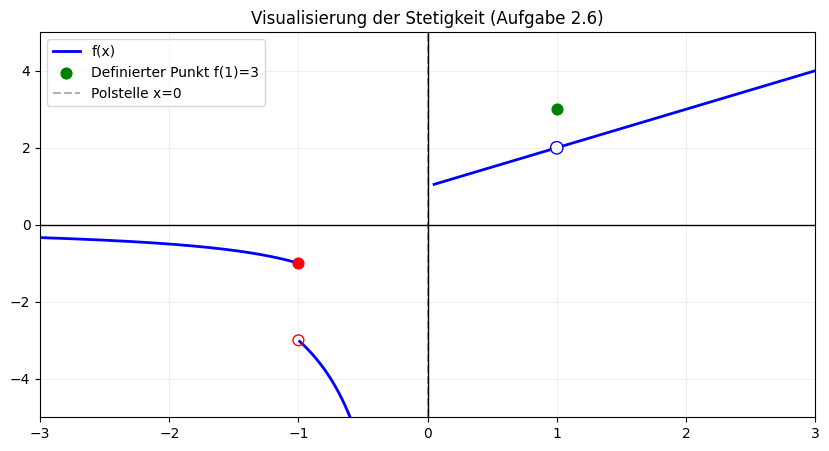


<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #eef6fc; border-radius: 6px;">
        🔍 Analyse der Stetigkeit - Lösungstabelle (Klicken zum Ausklappen)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


| Stelle | Typ | Mathematische Erklärung |
| :--- | :--- | :--- |
| **x = -1** | **Sprungstelle** | $\lim_{x \to -1^-} f(x) = -1$ und $\lim_{x \to -1^+} f(x) = -3$. Die Grenzwerte sind endlich, aber ungleich. |
| **x = 0** | **Polstelle** | Die Funktion divergiert gegen $\pm \infty$ ($\lim_{x \to 0^-} = -\infty$). |
| **x = 1** | **Hebbare Unstetigkeit** | Der Grenzwert existiert: $\lim_{x \to 1} \frac{x^2-1}{x-1} = 2$. Aber $f(1) = 3$. Da $2 \neq 3$, ist die Funktion dort unstetig. |

**Zusatzinfo:** Eine hebbare Unstetigkeit könnte man stetig machen, indem man $f(1) = 2$ neu definiert.


    </div>
</details>


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def zeige_loesung_26(titel, inhalt):
    box_md = f"""
<details style="margin: 15px 0; border: 1px solid #1f77b4; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #1f77b4; background: #eef6fc; border-radius: 6px;">
        🔍 {titel} (Klicken zum Ausklappen)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">

{inhalt}

    </div>
</details>
"""
    display(Markdown(box_md))

# --- VISUALISIERUNG ---
def plot_stetigkeit_26():
    # Definition der Teilbereiche
    x1 = np.linspace(-3, -1, 200)
    x2 = np.linspace(-0.99, -0.05, 200) 
    x3 = np.linspace(0.05, 0.95, 200)   
    x4 = np.linspace(1.05, 3, 200)
    
    plt.figure(figsize=(10, 5))
    
    # Funktionsgraphen
    plt.plot(x1, 1/x1, 'b', lw=2, label='f(x)')
    plt.plot(x2, 3/x2, 'b', lw=2)
    plt.plot(x3, (x3**2-1)/(x3-1), 'b', lw=2)
    plt.plot(x4, (x4**2-1)/(x4-1), 'b', lw=2)
    
    # Markierungen
    plt.scatter([-1], [-1], color='red', s=60, zorder=5) # Sprung Ende links
    plt.scatter([-1], [-3], edgecolors='red', facecolors='none', s=60, zorder=5) # Sprung Start rechts
    
    plt.scatter([1], [2], edgecolors='blue', facecolors='none', s=80, zorder=5) # Hebbare Lücke
    plt.scatter([1], [3], color='green', s=60, zorder=5, label='Definierter Punkt f(1)=3')
    
    plt.axvline(0, color='black', linestyle='--', alpha=0.3, label='Polstelle x=0')
    
    plt.ylim(-5, 5)
    plt.xlim(-3, 3)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.title("Visualisierung der Stetigkeit (Aufgabe 2.6)")
    plt.show()

# --- LÖSUNGSINHALT ALS MARKDOWN ---
sol_26 = r"""
| Stelle | Typ | Mathematische Erklärung |
| :--- | :--- | :--- |
| **x = -1** | **Sprungstelle** | $\lim_{x \to -1^-} f(x) = -1$ und $\lim_{x \to -1^+} f(x) = -3$. Die Grenzwerte sind endlich, aber ungleich. |
| **x = 0** | **Polstelle** | Die Funktion divergiert gegen $\pm \infty$ ($\lim_{x \to 0^-} = -\infty$). |
| **x = 1** | **Hebbare Unstetigkeit** | Der Grenzwert existiert: $\lim_{x \to 1} \frac{x^2-1}{x-1} = 2$. Aber $f(1) = 3$. Da $2 \neq 3$, ist die Funktion dort unstetig. |

**Zusatzinfo:** Eine hebbare Unstetigkeit könnte man stetig machen, indem man $f(1) = 2$ neu definiert.
"""

# Ausführung
plot_stetigkeit_26()
zeige_loesung_26("Analyse der Stetigkeit - Lösungstabelle", sol_26)

<a id="aufgabe6"></a>
## 📝 Aufgabe 2.7: Interaktive n-te Ableitungen & Taylor-Approximation

In dieser Aufgabe untersuchen wir die Funktionen nicht nur punktuell, sondern visualisieren, wie sich die Ableitungen oder Taylor-Polynome mit steigendem Grad $n$ verhalten.

### Definitionsbereiche der Funktionen:
1. **$f(x) = \sin(x)$**: $D = \mathbb{R}$ (Überall definiert)
2. **$f(x) = e^x$**: $D = \mathbb{R}$ (Überall definiert)
3. **$f(x) = \ln(x)$**: $D = \{x \in \mathbb{R} \mid x > 0\}$ (Nur positive reelle Zahlen)
4. **$f(x) = \frac{1}{1-x}$**: $D = \mathbb{R} \setminus \{1\}$ (Definiert für alle $x$ außer $x=1$)

---

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from ipywidgets import interact, IntSlider
from IPython.display import display, Markdown

# Sympy Symbole vorbereiten
x_sym = sp.Symbol('x')

def plot_taylor_approximation(f_name, n):
    """Visualisiert die Taylor-Approximation für eine gewählte Funktion."""
    
    # Funktionsauswahl
    if f_name == "sin(x)":
        f_expr = sp.sin(x_sym)
        x_range = np.linspace(-10, 10, 400)
        x0 = 0
    elif f_name == "exp(x)":
        f_expr = sp.exp(x_sym)
        x_range = np.linspace(-3, 3, 400)
        x0 = 0
    elif f_name == "ln(x)":
        f_expr = sp.log(x_sym)
        x_range = np.linspace(0.1, 4, 400)
        x0 = 1
    else: # 1/(1-x)
        f_expr = 1 / (1 - x_sym)
        x_range = np.linspace(-0.5, 0.9, 400)
        x0 = 0

    # Taylor-Polynom berechnen
    taylor_poly = f_expr.series(x_sym, x0, n+1).removeO()
    
    # Numerische Funktionen erstellen
    f_num = sp.lambdify(x_sym, f_expr, 'numpy')
    t_num = sp.lambdify(x_sym, taylor_poly, 'numpy')
    
    # Plot erstellen
    plt.figure(figsize=(12, 6))
    plt.plot(x_range, f_num(x_range), 'k--', lw=2, label=f"Original: ${sp.latex(f_expr)}$")
    
    # Taylor-Kurve (Falls t_num eine Konstante zurückgibt, Array daraus machen)
    t_vals = t_num(x_range)
    if isinstance(t_vals, (int, float, complex)):
        t_vals = np.full_like(x_range, t_vals)
        
    plt.plot(x_range, t_vals, 'r-', lw=2.5, label=f"Taylor-Polynom (Grad $n={n}$)")
    
    plt.axhline(0, color='black', lw=1)
    plt.axvline(x0, color='gray', linestyle=':', label=f"Entwicklungspunkt $x_0={x0}$")
    
    plt.title(f"Approximation von {f_name} durch n-te Ableitungen", fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Mathematische Anzeige des aktuellen Polynoms
    display(Markdown(f"**Aktuelles Polynom für $n={n}$:**"))
    display(Markdown(f"$$P_{n}(x) = {sp.latex(taylor_poly)}$$"))
    
    plt.show()

# Interaktiver Aufruf
interact(plot_taylor_approximation, 
         f_name=["sin(x)", "exp(x)", "ln(x)", "1/(1-x)"],
         n=IntSlider(min=0, max=15, step=1, value=1, description='Grad n'))

interactive(children=(Dropdown(description='f_name', options=('sin(x)', 'exp(x)', 'ln(x)', '1/(1-x)'), value='…

<function __main__.plot_taylor_approximation(f_name, n)>

<a id="aufgabe7"></a>
## 📝 Aufgabe 2.8: Übergangsbedingungen und Differenzierbarkeit

In den Ingenieurwissenschaften müssen Übergänge (z.B. zwischen zwei Bauteilen oder Schienenstücken) oft nicht nur stetig, sondern "glatt" sein. Das bedeutet, die Funktion muss an der Nahtstelle differenzierbar sein.

**Gegeben ist die Funktion $f(x)$:**
$$f(x) = \begin{cases} a \cdot e^x + b & \text{für } x \leq 0 \\ \cos(2x) + x^2 & \text{für } x > 0 \end{cases}$$

**Arbeitsauftrag:**
1. Bestimmen Sie die Parameter $a$ und $b$ so, dass die Funktion $f(x)$ an der Stelle $x = 0$ **stetig** und **differenzierbar** ist.
2. Notieren Sie die Bedingungen für:
   - Stetigkeit: $\lim_{x \to 0^-} f(x) = \lim_{x \to 0^+} f(x)$
   - Differenzierbarkeit: $\lim_{x \to 0^-} f'(x) = \lim_{x \to 0^+} f'(x)$
3. Visualisieren Sie die Funktion und ihre Ableitung, um den "glatten" Übergang zu prüfen.

---

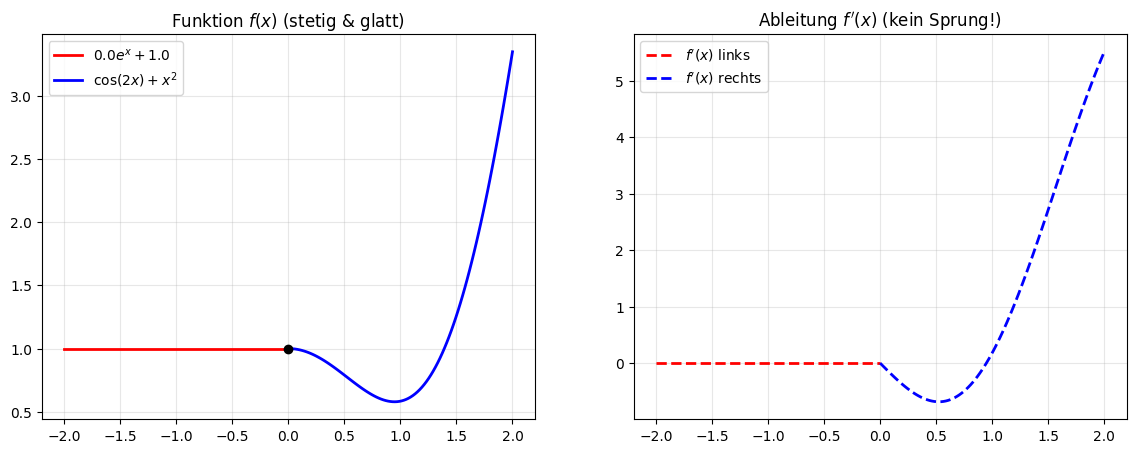


<details style="margin: 15px 0; border: 1px solid #e67e22; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #e67e22; background: #fef5ec; border-radius: 6px;">
        🔍 Lösungsweg & Parameter zu Aufgabe 2.8 (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">


**Schritt 1: Stetigkeitsbedingung bei $x=0$**
$$f_{links}(0) = a \cdot e^0 + b = a + b$$
$$f_{rechts}(0) = \cos(0) + 0^2 = 1$$
$\implies a + b = 1$

**Schritt 2: Differenzierbarkeitsbedingung bei $x=0$**
$$f'_{links}(x) = a \cdot e^x \implies f'_{links}(0) = a$$
$$f'_{rechts}(x) = -2\sin(2x) + 2x \implies f'_{rechts}(0) = 0$$
$\implies a = 0$

**Schritt 3: Parameter berechnen**
Aus $a=0$ folgt in der Stetigkeitsgleichung: $0 + b = 1 \implies b = 1$.

**Ergebnis:**
Die Parameter sind **$a = 0.0$** und **$b = 1.0$**.
Die Funktion lautet somit:
$$f(x) = \begin{cases} 1 & \text{für } x \leq 0 \\ \cos(2x) + x^2 & \text{für } x > 0 \end{cases}$$


    </div>
</details>


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Markdown

def zeige_loesung_28():
    # Symbole definieren
    x, a, b = sp.symbols('x a b')
    
    # Teilfunktionen definieren
    f_links = a * sp.exp(x) + b
    f_rechts = sp.cos(2*x) + x**2
    
    # 1. Bedingung: Stetigkeit bei x=0 (f_links(0) = f_rechts(0))
    bed1 = sp.Eq(f_links.subs(x, 0), f_rechts.subs(x, 0))
    
    # 2. Bedingung: Differenzierbarkeit bei x=0 (f_links'(0) = f_rechts'(0))
    f_links_abl = sp.diff(f_links, x)
    f_rechts_abl = sp.diff(f_rechts, x)
    bed2 = sp.Eq(f_links_abl.subs(x, 0), f_rechts_abl.subs(x, 0))
    
    # Gleichungssystem lösen
    loesung = sp.solve((bed1, bed2), (a, b))
    a_val = float(loesung[a])
    b_val = float(loesung[b])
    
    # --- PLOT ERSTELLEN ---
    x_l = np.linspace(-2, 0, 100)
    x_r = np.linspace(0, 2, 100)
    
    y_l = a_val * np.exp(x_l) + b_val
    y_r = np.cos(2*x_r) + x_r**2
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Funktionsplot (Raw-String für Label wegen \cos)
    ax[0].plot(x_l, y_l, 'r', lw=2, label=rf'${a_val:.1f} e^x + {b_val:.1f}$')
    ax[0].plot(x_r, y_r, 'b', lw=2, label=r'$\cos(2x) + x^2$')
    ax[0].scatter([0], [a_val + b_val], color='black', zorder=5)
    ax[0].set_title("Funktion $f(x)$ (stetig & glatt)")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Ableitungsplot
    y_l_abl = a_val * np.exp(x_l)
    y_r_abl = -2 * np.sin(2*x_r) + 2*x_r
    ax[1].plot(x_l, y_l_abl, 'r--', lw=2, label="$f'(x)$ links")
    ax[1].plot(x_r, y_r_abl, 'b--', lw=2, label="$f'(x)$ rechts")
    ax[1].set_title("Ableitung $f'(x)$ (kein Sprung!)")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.show()

    # --- LÖSUNGS-TEXT (Raw-String wegen der vielen Backslashes) ---
    inhalt = r"""
**Schritt 1: Stetigkeitsbedingung bei $x=0$**
$$f_{links}(0) = a \cdot e^0 + b = a + b$$
$$f_{rechts}(0) = \cos(0) + 0^2 = 1$$
$\implies a + b = 1$

**Schritt 2: Differenzierbarkeitsbedingung bei $x=0$**
$$f'_{links}(x) = a \cdot e^x \implies f'_{links}(0) = a$$
$$f'_{rechts}(x) = -2\sin(2x) + 2x \implies f'_{rechts}(0) = 0$$
$\implies a = 0$

**Schritt 3: Parameter berechnen**
Aus $a=0$ folgt in der Stetigkeitsgleichung: $0 + b = 1 \implies b = 1$.

**Ergebnis:**
Die Parameter sind **$a = 0.0$** und **$b = 1.0$**.
Die Funktion lautet somit:
$$f(x) = \begin{cases} 1 & \text{für } x \leq 0 \\ \cos(2x) + x^2 & \text{für } x > 0 \end{cases}$$
"""
    
    # Klappbox (Raw-String verhindert SyntaxWarnings im HTML/CSS)
    box_md = rf"""
<details style="margin: 15px 0; border: 1px solid #e67e22; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #e67e22; background: #fef5ec; border-radius: 6px;">
        🔍 Lösungsweg & Parameter zu Aufgabe 2.8 (Klicken)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">

{inhalt}

    </div>
</details>
"""
    display(Markdown(box_md))

# Ausführung
zeige_loesung_28()

<a id="aufgabe8"></a>
# 📝 Aufgabe 2.9: Analyse der Stetigkeit und das $\epsilon$-$\delta$-Kriterium

---

### Teil a) Das $\epsilon$-$\delta$-Kriterium (Interaktive Analyse)

Betrachten Sie die drei Funktionen:
* $f_1(x) = x^2$ (Überall stetig)
* $f_2(x) = \frac{x^2 - 1}{x - 1}$ (Definitionslücke bei $x = 1$)
* $f_3(x) = \begin{cases} x + 1 & x < 1 \\ x + 3 & x \geq 1 \end{cases}$ (Sprungstelle bei $x = 1$)

#### 1. Nachweis der Stetigkeit
Das $\epsilon$-$\delta$-Kriterium besagt: Eine Funktion $f$ ist an der Stelle $x_0$ stetig, wenn zu jedem $\epsilon > 0$ ein $\delta > 0$ existiert, sodass für alle $x$ aus dem Definitionsbereich gilt:
$$|x - x_0| < \delta \implies |f(x) - f(x_0)| < \epsilon$$
Im interaktiven Plot lässt sich zeigen: Je kleiner $\epsilon$ gewählt wird, desto kleiner muss i.d.R. auch $\delta$ sein, damit der Funktionsgraph innerhalb des "Epsilon-Schlauchs" bleibt.

#### 2. Stetige Fortsetzbarkeit von $f_2(x)$
Untersuchen Sie die Funktion $f_2(x)$ an der Stelle $x_0 = 1$. Durch Faktorisieren des Zählers (3. Binomische Formel) ergibt sich:
$$f_2(x) = \frac{(x - 1)(x + 1)}{x - 1} = x + 1 \quad \text{für } x \neq 1$$
Daraus berechnet sich der Grenzwert:
$$\lim_{x \to 1} f_2(x) = \lim_{x \to 1} (x + 1) = 2$$
Die Funktion besitzt an der Stelle $x=1$ eine **hebbare Unstetigkeit**. Sie wird stetig fortgesetzt durch die Definition $f_2(1) := 2$.

#### 3. Widerlegung der Stetigkeit bei $f_3(x)$
An der Sprungstelle $x_0 = 1$ gilt für den linksseitigen Grenzwert $L^- = 2$ und für den rechtsseitigen Grenzwert $L^+ = 4$. Wählt man ein $\epsilon < \frac{|L^+ - L^-|}{2}$ (z.B. $\epsilon = 0.5$), so liegen die Funktionswerte unmittelbar links von $x_0$ außerhalb des Intervalls $[f(x_0) - \epsilon, f(x_0) + \epsilon]$, unabhängig von der Wahl von $\delta$.

---

### Teil b) Klassifizierung von Unstetigkeiten

| Typ | Charakteristik | Mathematische Bedingung |
| :--- | :--- | :--- |
| **Sprungstelle** | Einseitige Grenzwerte existieren, sind aber verschieden. | $\lim_{x \to x_0^-} f(x) \neq \lim_{x \to x_0^+} f(x)$ |
| **Polstelle** | Funktionswerte streben gegen Unendlich. | $\lim_{x \to x_0} f(x) = \pm\infty$ |
| **Hebbare Lücke** | Grenzwert existiert, ist aber $\neq f(x_0)$. | $\lim_{x \to x_0} f(x) = L \neq f(x_0)$ |
| **Wesentliche Unst.** | Unendliche Oszillation ohne Grenzwert. | $\nexists \lim_{x \to x_0} f(x)$ |

---

# 💡 Lösungsweg & Hinweise zu Aufgabe 2.9

---

### Zu Teil a) Analyse der Einzelfunktionen

#### 1. Fall: Stetigkeit bei $f_1(x) = x^2$
Um die Stetigkeit an $x_0 = 1$ nachzuweisen, nutzen wir die Definition:
1. **Funktionswert:** $f(1) = 1^2 = 1$
2. **Grenzwert:** $\lim_{x \to 1} x^2 = 1$
3. **Schlussfolgerung:** Da $\lim_{x \to 1} f(1) = f(1)$, ist die Funktion stetig. 
   * *Interaktiver Hinweis:* Man kann für jedes noch so kleine $\epsilon$ ein $\delta$ finden (z.B. $\delta \approx \frac{\epsilon}{3}$ in der Nähe von $x=1$), sodass der Graph die "Box" nicht oben oder unten verlässt.

#### 2. Fall: Hebbare Unstetigkeit bei $f_2(x) = \frac{x^2-1}{x-1}$
Der Lösungsweg zur stetigen Fortsetzung erfolgt in drei Schritten:
* **Definitionsbereich prüfen:** $x-1 \neq 0 \implies D = \mathbb{R} \setminus \{1\}$.
* **Term vereinfachen:** $$\frac{x^2-1}{x-1} = \frac{(x-1)(x+1)}{x-1} = x+1$$
* **Limes berechnen:** Obwohl der Punkt $x=1$ nicht definiert ist, streben die Werte von links und rechts gegen $1+1 = 2$.
* **Fortsetzung:** Die Lücke wird "gehoben", indem man den isolierten Punkt $(1, 2)$ in den Graphen einzeichnet.

#### 3. Fall: Sprungstelle bei $f_3(x)$
Hier betrachten wir die einseitigen Grenzwerte an $x_0 = 1$:
* **Linksseitig ($x \to 1^-$):** $\lim_{x \to 1^-} (x+1) = 2$
* **Rechtsseitig ($x \to 1^+$):** $\lim_{x \to 1^+} (x+3) = 4$
* **Differenz:** Da $2 \neq 4$, liegt ein Sprung der Höhe $2$ vor. 
   * *$\epsilon$-$\delta$ Beweis:* Wählt man $\epsilon = 0.5$, müsste die Funktion zwischen $3.5$ und $4.5$ bleiben. Da sie aber links vom Sprung sofort auf $2$ abfällt, gibt es kein $\delta$, das diesen Sprung "überbrücken" könnte.

---

### Zu Teil b) Zusammenfassung der Unstetigkeitstypen

Um die Unstetigkeiten im Plot korrekt zu identifizieren, hilft diese Checkliste:

1.  **Gibt es einen "unendlichen" Ausschlag?** $\rightarrow$ **Polstelle** (meist Nennernullstelle, die sich nicht wegkürzen lässt).
2.  **Gibt es eine Lücke, aber die Enden treffen sich?** $\rightarrow$ **Hebbare Unstetigkeit** (Loch im Graphen).
3.  **Gibt es eine vertikale Stufe?** $\rightarrow$ **Sprungstelle** (typisch für abschnittsweise definierte Funktionen).
4.  **Zittert die Funktion wild an einer Stelle?** $\rightarrow$ **Wesentliche Unstetigkeit** (z.B. bei $f(x) = \sin(\frac{1}{x})$).

---

interactive(children=(Dropdown(description='f_type', options=('Stetig (f1)', 'Stetig fortsetzbar (f2)', 'Sprun…

---

### Teil b) Übersicht aller Unstetigkeitsarten

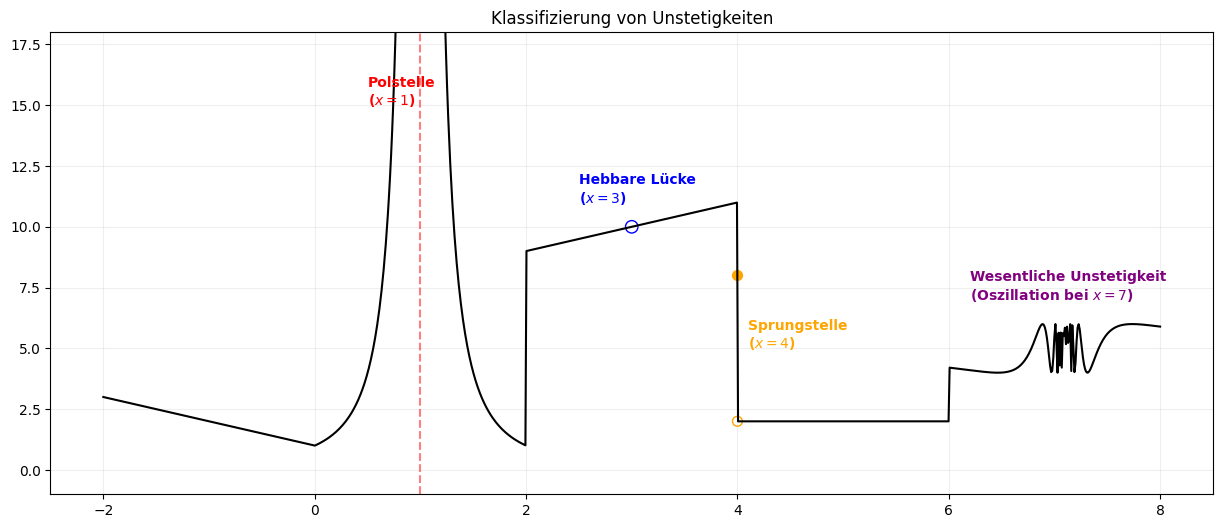

In [4]:
# ==========================================
# KORRIGIERTER CODE (Ohne SyntaxWarnings)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from ipywidgets import interact, widgets
from IPython.display import display, Markdown

x_sym = sp.Symbol('x')

def interactive_stetigkeit(f_type="Stetig (f1)", delta=0.2, epsilon=0.5):
    x0 = 1.0
    plt.figure(figsize=(12, 7))
    
    if f_type == "Stetig (f1)":
        f_expr = x_sym**2
        f_num = lambda x: x**2
        y0 = float(f_expr.subs(x_sym, x0))
        title = r"Stetige Funktion: $f_1(x) = x^2$"
        
    elif f_type == "Stetig fortsetzbar (f2)":
        f_expr = (x_sym**2 - 1) / (x_sym - 1)
        f_num = lambda x: np.where(np.isclose(x, 1.0), np.nan, (x**2 - 1) / (x - 1))
        y0 = float(sp.limit(f_expr, x_sym, x0))
        title = r"Hebbare Unstetigkeit: $f_2(x) = \frac{x^2-1}{x-1}$"
        
    else: 
        f_num = lambda x: np.where(x < 1, x + 1, x + 3)
        y0 = 4.0 
        title = r"Sprungstelle: $f_3(x)$"

    x_vals = np.linspace(x0 - 1.5, x0 + 1.5, 400)
    y_vals = f_num(x_vals)

    plt.plot(x_vals, y_vals, label="f(x)", color="#1f77b4", lw=2.5)
    
    # Hier wurde das 'fr' für f-string + raw-string hinzugefügt:
    plt.axhspan(y0 - epsilon, y0 + epsilon, color='green', alpha=0.15, label=fr'Epsilon-Band ($\epsilon={epsilon}$)')
    plt.axhline(y0, color='green', linestyle='--', alpha=0.4)
    
    # Ebenfalls 'fr' für den Delta-Bereich:
    plt.axvspan(x0 - delta, x0 + delta, color='orange', alpha=0.15, label=fr'Delta-Bereich ($\delta={delta}$)')
    plt.axvline(x0, color='orange', linestyle='--', alpha=0.4)

    plt.scatter([x0], [y0], color='red', zorder=5, s=100, label=fr'Untersuchungspunkt $P({x0}|{y0})$')

    y_check_left = y0 - delta if f_type == "Stetig fortsetzbar (f2)" else f_num(x0 - delta)
    y_check_right = y0 + delta if f_type == "Stetig fortsetzbar (f2)" else f_num(x0 + delta)
    
    is_stetig = np.abs(y_check_left - y0) <= epsilon and np.abs(y_check_right - y0) <= epsilon
    
    status_color = "green" if is_stetig else "red"
    plt.title(f"{title}\nStatus: {'BEDINGUNG ERFÜLLT' if is_stetig else 'BEDINGUNG VERLETZT'}", 
              color=status_color, fontsize=14, fontweight='bold')

    plt.ylim(y0 - 2, y0 + 2)
    plt.xlim(x0 - 1.5, x0 + 1.5)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    plt.show()

    if f_type == "Stetig fortsetzbar (f2)":
        # Raw-String für die Markdown-Ausgabe korrigiert:
        display(Markdown(fr"**Limes-Analyse:** $\lim_{{x \to 1}} \frac{{x^2-1}}{{x-1}} = {y0}$."))

# Widgets mit Raw-Strings für die Beschriftung:
interact(interactive_stetigkeit, 
         f_type=["Stetig (f1)", "Stetig fortsetzbar (f2)", "Sprungfunktion (f3)"],
         delta=widgets.FloatSlider(value=0.2, min=0.01, max=1.0, step=0.05, description=r'Delta ($\delta$)'),
         epsilon=widgets.FloatSlider(value=0.5, min=0.05, max=1.5, step=0.05, description=r'Epsilon ($\epsilon$)'))


# ==========================================
# 3. TEIL B: ALLE UNSTETIGKEITSARTEN
# ==========================================

def plot_all_singularities():
    display(Markdown("---"))
    display(Markdown("### Teil b) Übersicht aller Unstetigkeitsarten"))
    
    x = np.linspace(-2, 8, 1000)
    
    def f_total(x):
        # Zusammenstellung verschiedener Typen
        if x < 0: return -x + 1                 # Stetig
        if x < 2: return 1 / (x - 1.001)**2     # Polstelle bei 1
        if x < 4: return (x**2 - 9)/(x - 3) + 4 # Hebbar bei 3 (Limes=10)
        if x < 6: return 2                      # Sprung von 4 auf 2
        return np.sin(1/(x-7.1)) + 5            # Wesentliche Unstetigkeit (Oszillation)

    # Vektorisierung für den Plot
    f_vec = np.vectorize(f_total)
    y = f_vec(x)
    y[y > 20] = np.nan # Polstelle kappen für Optik

    plt.figure(figsize=(15, 6))
    plt.plot(x, y, color='black', lw=1.5)
    
    # Markierungen & Texte
    plt.axvline(1, color='red', linestyle='--', alpha=0.5)
    plt.text(0.5, 15, "Polstelle\n($x=1$)", color='red', fontweight='bold')
    
    plt.scatter([3], [10], facecolors='none', edgecolors='blue', s=80)
    plt.text(2.5, 11, "Hebbare Lücke\n($x=3$)", color='blue', fontweight='bold')
    
    plt.scatter([4], [8], color='orange', s=50)
    plt.scatter([4], [2], facecolors='none', edgecolors='orange', s=50)
    plt.text(4.1, 5, "Sprungstelle\n($x=4$)", color='orange', fontweight='bold')
    
    plt.text(6.2, 7, "Wesentliche Unstetigkeit\n(Oszillation bei $x=7$)", color='purple', fontweight='bold')

    plt.title("Klassifizierung von Unstetigkeiten")
    plt.ylim(-1, 18)
    plt.grid(True, alpha=0.2)
    plt.show()

# Aufruf von Teil b
plot_all_singularities()


<a id="aufgabe10"></a>
## 📈 Aufgabe 2.10: Interaktive Kurvendiskussion

Untersuchen Sie die folgenden Funktionen auf ihre charakteristischen Eigenschaften:
1. **Definitionsbereich** und Grenzwerte an den Rändern.
2. **Extremstellen** (notwendige und hinreichende Bedingung).
3. **Krümmungsverhalten** (Wendepunkte).

**Die Test-Funktionen:**
* $f_1(x) = x \cdot \ln(x)$
* $f_2(x) = x \cdot e^{-x^2}$

---

### 2.10 Interaktive Analysen


<details style="margin: 15px 0; border: 1px solid #9b59b6; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #9b59b6; background: #f5eef8; border-radius: 6px;">
        🔍 Kurvendiskussion zu $f(x) = x \cdot \ln(x)$ (Klicken zum Öffnen)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">
    


**1. Mathematische Analyse:**
* Erste Ableitung: $f'(x) = \log{\left(x \right)} + 1$
* Zweite Ableitung: $f''(x) = \frac{1}{x}$

**2. Charakteristische Punkte:**
* **Tiefpunkt**: bei $x \approx 0.368$ mit $y \approx -0.368$

* **Randverhalten**: $\lim_{x \to 0^+} x \ln(x) = 0$ (hebbare Lücke).

**3. Grafische Darstellung:**


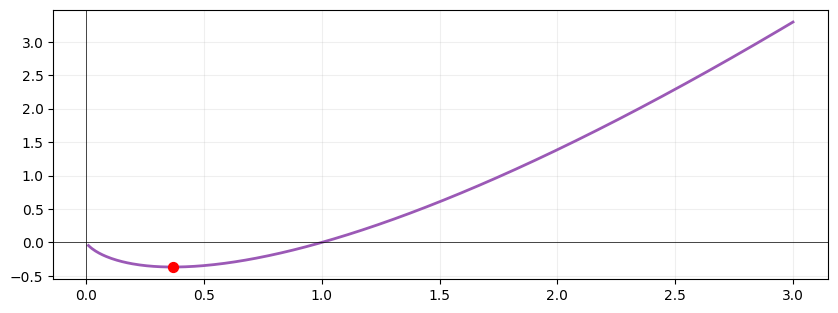

</div></details>


<details style="margin: 15px 0; border: 1px solid #9b59b6; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #9b59b6; background: #f5eef8; border-radius: 6px;">
        🔍 Kurvendiskussion zu $f(x) = x \cdot e^{-x^2}$ (Klicken zum Öffnen)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">
    


**1. Mathematische Analyse:**
* Erste Ableitung: $f'(x) = - 2 x^{2} e^{- x^{2}} + e^{- x^{2}}$
* Zweite Ableitung: $f''(x) = 4 x^{3} e^{- x^{2}} - 6 x e^{- x^{2}}$

**2. Charakteristische Punkte:**
* **Tiefpunkt**: bei $x \approx -0.707$ mit $y \approx -0.429$
* **Hochpunkt**: bei $x \approx 0.707$ mit $y \approx 0.429$

* **Symmetrie**: Punktsymmetrisch, da $f(-x) = -f(x)$.

**3. Grafische Darstellung:**


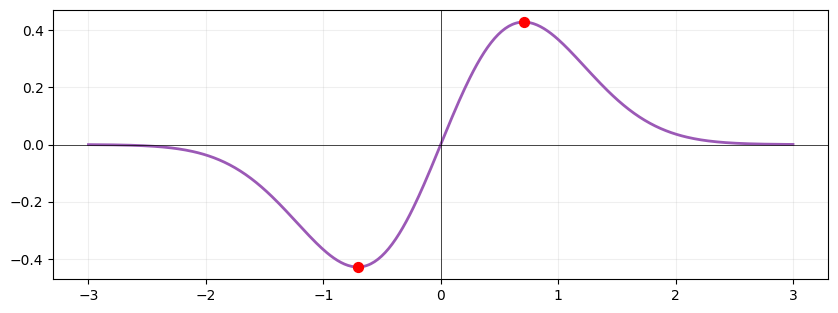

</div></details>

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Markdown

def zeige_kurvendiskussion(f_choice):
    x_sym = sp.Symbol('x', real=True)
    
    # Funktionsauswahl und Setup
    if f_choice == "x * ln(x)":
        f_expr = x_sym * sp.log(x_sym)
        x_plot = np.linspace(0.01, 3, 400)
        titel_latex = r"f(x) = x \cdot \ln(x)"
    else:
        f_expr = x_sym * sp.exp(-x_sym**2)
        x_plot = np.linspace(-3, 3, 400)
        titel_latex = r"f(x) = x \cdot e^{-x^2}"

    # Ableitungen berechnen
    f1 = sp.diff(f_expr, x_sym)
    f2 = sp.diff(f1, x_sym)
    
    # Extrema berechnen
    extrema_x = [ex for ex in sp.solve(f1, x_sym) if ex.is_real]
    
    # Numerische Funktionen für den Plot
    f_num = sp.lambdify(x_sym, f_expr, 'numpy')
    
    # --- LÖSUNGS-INHALT GENERIEREN ---
    points_info = ""
    for ex in extrema_x:
        ex_v = float(ex)
        ey_v = float(f_expr.subs(x_sym, ex))
        typ = "Hochpunkt" if f2.subs(x_sym, ex) < 0 else "Tiefpunkt"
        # Wir nutzen Doppel-Backslash \\approx damit Python es ignoriert
        points_info += f"* **{typ}**: bei $x \\approx {ex_v:.3f}$ mit $y \\approx {ey_v:.3f}$\n"

    besonderheit = ""
    if f_choice == "x * ln(x)":
        besonderheit = r"* **Randverhalten**: $\lim_{x \to 0^+} x \ln(x) = 0$ (hebbare Lücke)."
    else:
        besonderheit = r"* **Symmetrie**: Punktsymmetrisch, da $f(-x) = -f(x)$."

    # Hier nutzen wir nur Markdown() und bauen den String vorsichtig zusammen
    inhalt_md = f"""
**1. Mathematische Analyse:**
* Erste Ableitung: $f'(x) = {sp.latex(f1)}$
* Zweite Ableitung: $f''(x) = {sp.latex(f2)}$

**2. Charakteristische Punkte:**
{points_info}
{besonderheit}

**3. Grafische Darstellung:**
"""

    # --- DIE KLAPPBOX ---
    box_html = f"""
<details style="margin: 15px 0; border: 1px solid #9b59b6; border-radius: 8px; font-family: sans-serif;">
    <summary style="cursor: pointer; padding: 12px; font-weight: bold; color: #9b59b6; background: #f5eef8; border-radius: 6px;">
        🔍 Kurvendiskussion zu ${titel_latex}$ (Klicken zum Öffnen)
    </summary>
    <div style="padding: 20px; background: white; border-top: 1px solid #eee;">
    """
    
    display(Markdown(box_html))
    display(Markdown(inhalt_md))
    
    # Plot erstellen
    plt.figure(figsize=(10, 3.5))
    plt.plot(x_plot, f_num(x_plot), color='#9b59b6', lw=2)
    for ex in extrema_x:
        plt.scatter([float(ex)], [float(f_expr.subs(x_sym, ex))], color='red', s=50, zorder=5)
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True, alpha=0.2)
    plt.show()
    
    display(Markdown("</div></details>"))

# Ausführung
display(Markdown("### 2.10 Interaktive Analysen"))
zeige_kurvendiskussion("x * ln(x)")
zeige_kurvendiskussion("x * exp(-x^2)")

<a id="tipps"></a>
## 💡 Lösungstipps

### Tipps zu Aufgabe 2.7 (Taylor-Approximation)
* **Der Entwicklungspunkt $x_0$:** Das Taylor-Polynom ist am genauesten in der unmittelbaren Nähe von $x_0$. Je weiter du dich von diesem Punkt entfernst, desto höher muss der Grad $n$ sein, um eine gute Annäherung zu erhalten.
* **Symmetrie nutzen:** Bei Funktionen wie $\sin(x)$ (ungerade) fallen alle geraden Ableitungen an der Stelle $x_0=0$ weg. Das Polynom enthält also nur ungerade Potenzen ($x^1, x^3, x^5, \dots$).
* **Fakultät im Nenner:** Vergiss beim händischen Rechnen nicht das $n!$ im Nenner jedes Terms ($f^{(n)}(x_0) / n!$). Ohne diesen Teiler würde das Polynom viel zu steil ansteigen.



### Tipps zu Aufgabe 2.8 (Differenzierbarkeit an Nahtstellen)
* **Zweistufiges Prüfen:** Eine Funktion ist an einer Nahtstelle $x_0$ nur dann differenzierbar, wenn sie dort erstens **stetig** ist ($f_{links} = f_{rechts}$) und zweitens die **Steigungen** übereinstimmen ($f'_{links} = f'_{rechts}$).
* **Vorsicht bei Konstanten:** Beim Ableiten fällt der Parameter $b$ (die vertikale Verschiebung) weg. Bestimme daher oft zuerst $a$ über die Ableitung und danach $b$ über die Stetigkeit.
* **Grafische Kontrolle:** Wenn du im Plot einen "Knick" siehst, ist die Funktion zwar stetig, aber nicht differenzierbar. Ein "Sprung" bedeutet, dass sie nicht einmal stetig ist.

### Tipps zu Aufgabe 2.9 (Kurvendiskussion & Extremwerte)
* **Notwendige Bedingung:** Suche die Stellen, an denen die erste Ableitung Null wird ($f'(x) = 0$). Das sind deine Kandidaten für Maxima, Minima oder Sattelpunkte.
* **Hinreichende Bedingung:** Setze diese Kandidaten in die zweite Ableitung $f''(x)$ ein:
    * $f''(x) < 0 \implies$ Hochpunkt (Maximum)
    * $f''(x) > 0 \implies$ Tiefpunkt (Minimum)
* **Logarithmen-Trick:** Wenn du Funktionen wie $f(x) = x \cdot \ln(x)$ ableitest, denke an den Definitionsbereich ($x > 0$). Der Logarithmus $\ln(x)$ geht für $x \to 0$ gegen $-\infty$, was oft interessante Grenzwerte am Rand des Definitionsbereichs liefert.

---

## 📚 Weitere Ressourcen

- [Vorheriges Aufgabeblatt](./Mathematik_II_Uebung_01.ipynb)
- [Nächstes Aufgabeblatt](./Mathematik_II_Uebung_03.ipynb)

**Viel Erfolg beim Bearbeiten der Aufgaben!** 🎓